In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import butter, sosfilt, sosfreqz
import os
import scienceplots

In [16]:

wav_path = 'input_data/tap_cancel/voltage.wav'

if not os.path.exists(wav_path):
    raise FileNotFoundError(f"WAV file not found: {wav_path}")

sample_rate, voltage = wavfile.read(wav_path)
print(f"Loaded '{wav_path}' at {sample_rate} Hz")

wav_path = 'input_data/tap_cancel/current.wav'

if not os.path.exists(wav_path):
    raise FileNotFoundError(f"WAV file not found: {wav_path}")

sample_rate, current = wavfile.read(wav_path)
print(f"Loaded '{wav_path}' at {sample_rate} Hz")

wav_path = 'input_data/tap_cancel/cancelled.wav'

if not os.path.exists(wav_path):
    raise FileNotFoundError(f"WAV file not found: {wav_path}")

sample_rate, cancelled = wavfile.read(wav_path)
print(f"Loaded '{wav_path}' at {sample_rate} Hz")

# Normalize if needed
#if data.dtype != np.float32:
#    data = data / np.max(np.abs(data))

# Handle stereo by selecting one channel



Loaded 'input_data/tap_cancel/voltage.wav' at 44100 Hz
Loaded 'input_data/tap_cancel/current.wav' at 44100 Hz
Loaded 'input_data/tap_cancel/cancelled.wav' at 44100 Hz


/var/folders/kd/v3035tq94wdfg4dqh988_zcr0000gp/T/ipykernel_29479/791418431.py:6: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, voltage = wavfile.read(wav_path)
/var/folders/kd/v3035tq94wdfg4dqh988_zcr0000gp/T/ipykernel_29479/791418431.py:14: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, current = wavfile.read(wav_path)
/var/folders/kd/v3035tq94wdfg4dqh988_zcr0000gp/T/ipykernel_29479/791418431.py:22: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, cancelled = wavfile.read(wav_path)


In [17]:
voltage = [x / ((2.0**31) - 1.0) for x in voltage] #Convert to normalised floating point
voltage = [x * 11.0 for x in voltage] #Convert to Volts
voltage = [x * 1000.0 for x in voltage] #Convert to mV

v_time = np.arange(len(voltage)) / sample_rate

current = [x / ((2.0**31) - 1.0) for x in current] #Convert to normalised floating point
current = [x * 3.0 for x in current] #Convert to current in Amps
current = [x * 1000.0 for x in current] #Convert to current in milliAmps

c_time = np.arange(len(current)) / sample_rate


cancelled = [x / ((2.0**31) - 1.0) for x in cancelled] #Convert to normalised floating point
cancelled = [x * 3.0 for x in cancelled] #Convert to current in Amps
cancelled = [x * 1000.0 for x in cancelled] #Convert to current in milliAmps



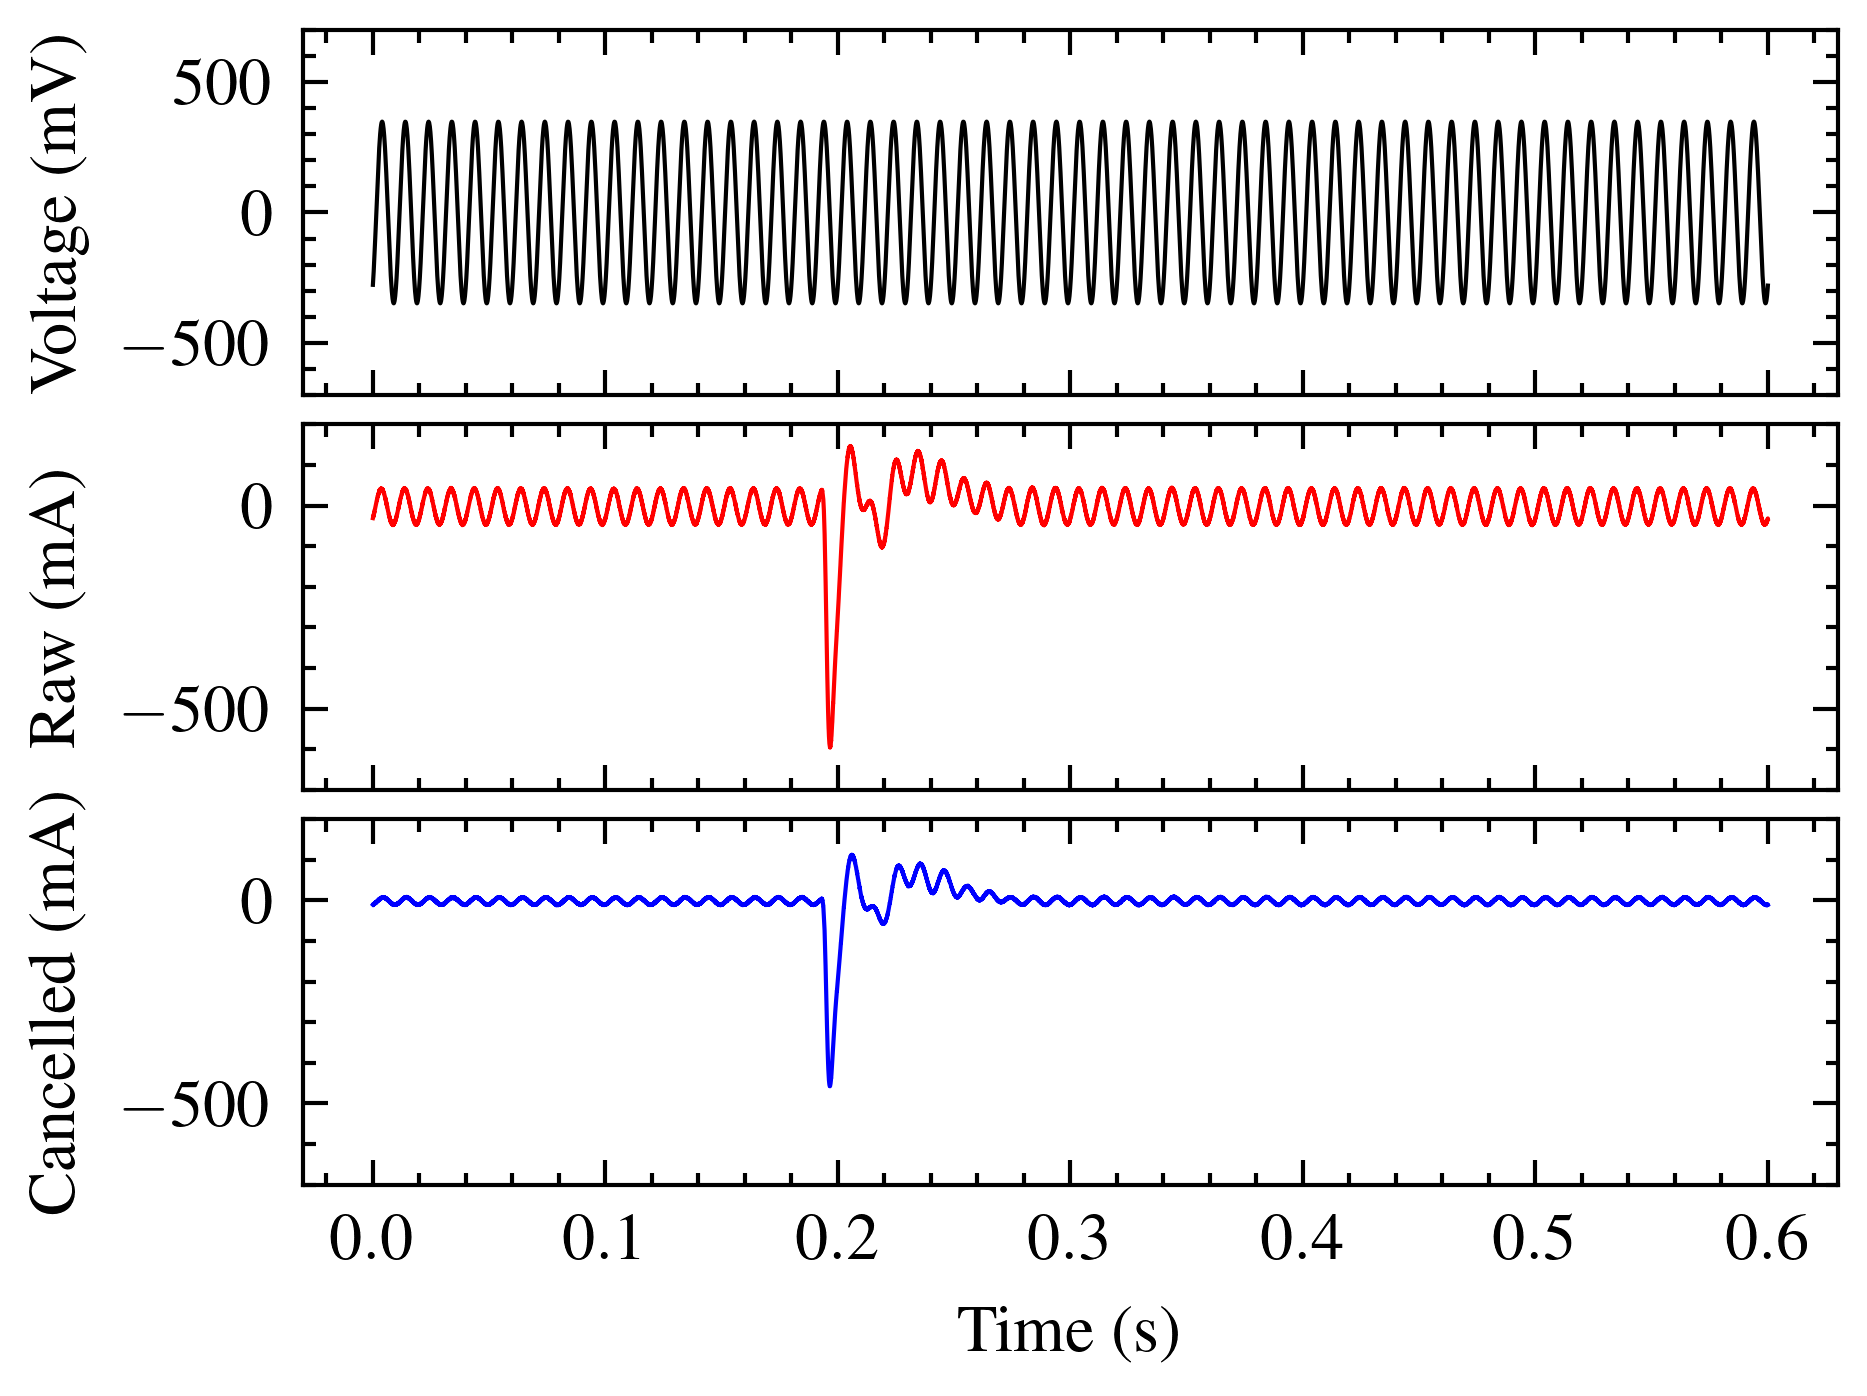

In [25]:
import matplotlib as mpl
from matplotlib import gridspec

#set Times New Roman as the default font
#mpl.rcParams['font.family'] = 'Times New Roman'

# Create figure and axis
fig = plt.figure()

gs = gridspec.GridSpec(3, 1, height_ratios=[1, 1, 1]) 


# Set the time range to zoom in (in seconds)
start_time = 5.2
end_time = 5.8

# Convert to sample indices
start_idx = int(start_time * sample_rate)
end_idx = int(end_time * sample_rate)
range_idx = end_idx - start_idx


# Plot voltage
ax1 = plt.subplot(gs[0])
ax1.set_ylabel('Voltage (mV)')
ax1.plot(v_time[0:range_idx], voltage[0:range_idx], label='Voltage', linewidth=0.5)
ax1.set_ylim([-700,700])

#ax1.tick_params(axis='y', labelcolor='tab:blue')
#ax1.yaxis.set_major_locator(plt.MaxNLocator(6))

#ax1.set_ylim([])
#ax1.set_xlim([1,20000])

#plt.grid(True, which='major',axis='both', linestyle='--', linewidth=0.5)


# Plot phase on secondary axis
ax2 = plt.subplot(gs[1], sharex = ax1)
ax2.set_ylabel('Raw (mA)')
ax2.plot(c_time[0:range_idx], current[start_idx:end_idx],label='Current',color='red', linewidth=0.5)  # Dotted red line
#ax2.tick_params(axis='y', labelcolor='tab:red')
#ax2.yaxis.set_major_locator(plt.MaxNLocator(4))

ax2.set_ylim([-700,200])
#ax2.set_xlabel('Frequency (Hz)')

ax3 = plt.subplot(gs[2], sharex = ax1)
ax3.set_ylabel('Cancelled (mA)')
ax3.plot(c_time[0:range_idx], cancelled[start_idx:end_idx],label='Cancelled',color='blue', linewidth=0.5)  # Dotted red line
ax3.set_ylim([-700,200])

plt.setp(ax1.get_xticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)
plt.subplots_adjust(hspace=.08)

#plt.grid(True, which='major',axis='both', linestyle='--', linewidth=0.5)

# Add grid and title
#plt.title('Impedance and Phase vs Frequency')
#fig.tight_layout()
ax3.set_xlabel('Time (s)')

plt.style.use(['science','ieee'])

fig.align_ylabels()

# Save the figure as EPS
plt.savefig('outputs/cancelled_tap.eps', format='eps')

plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

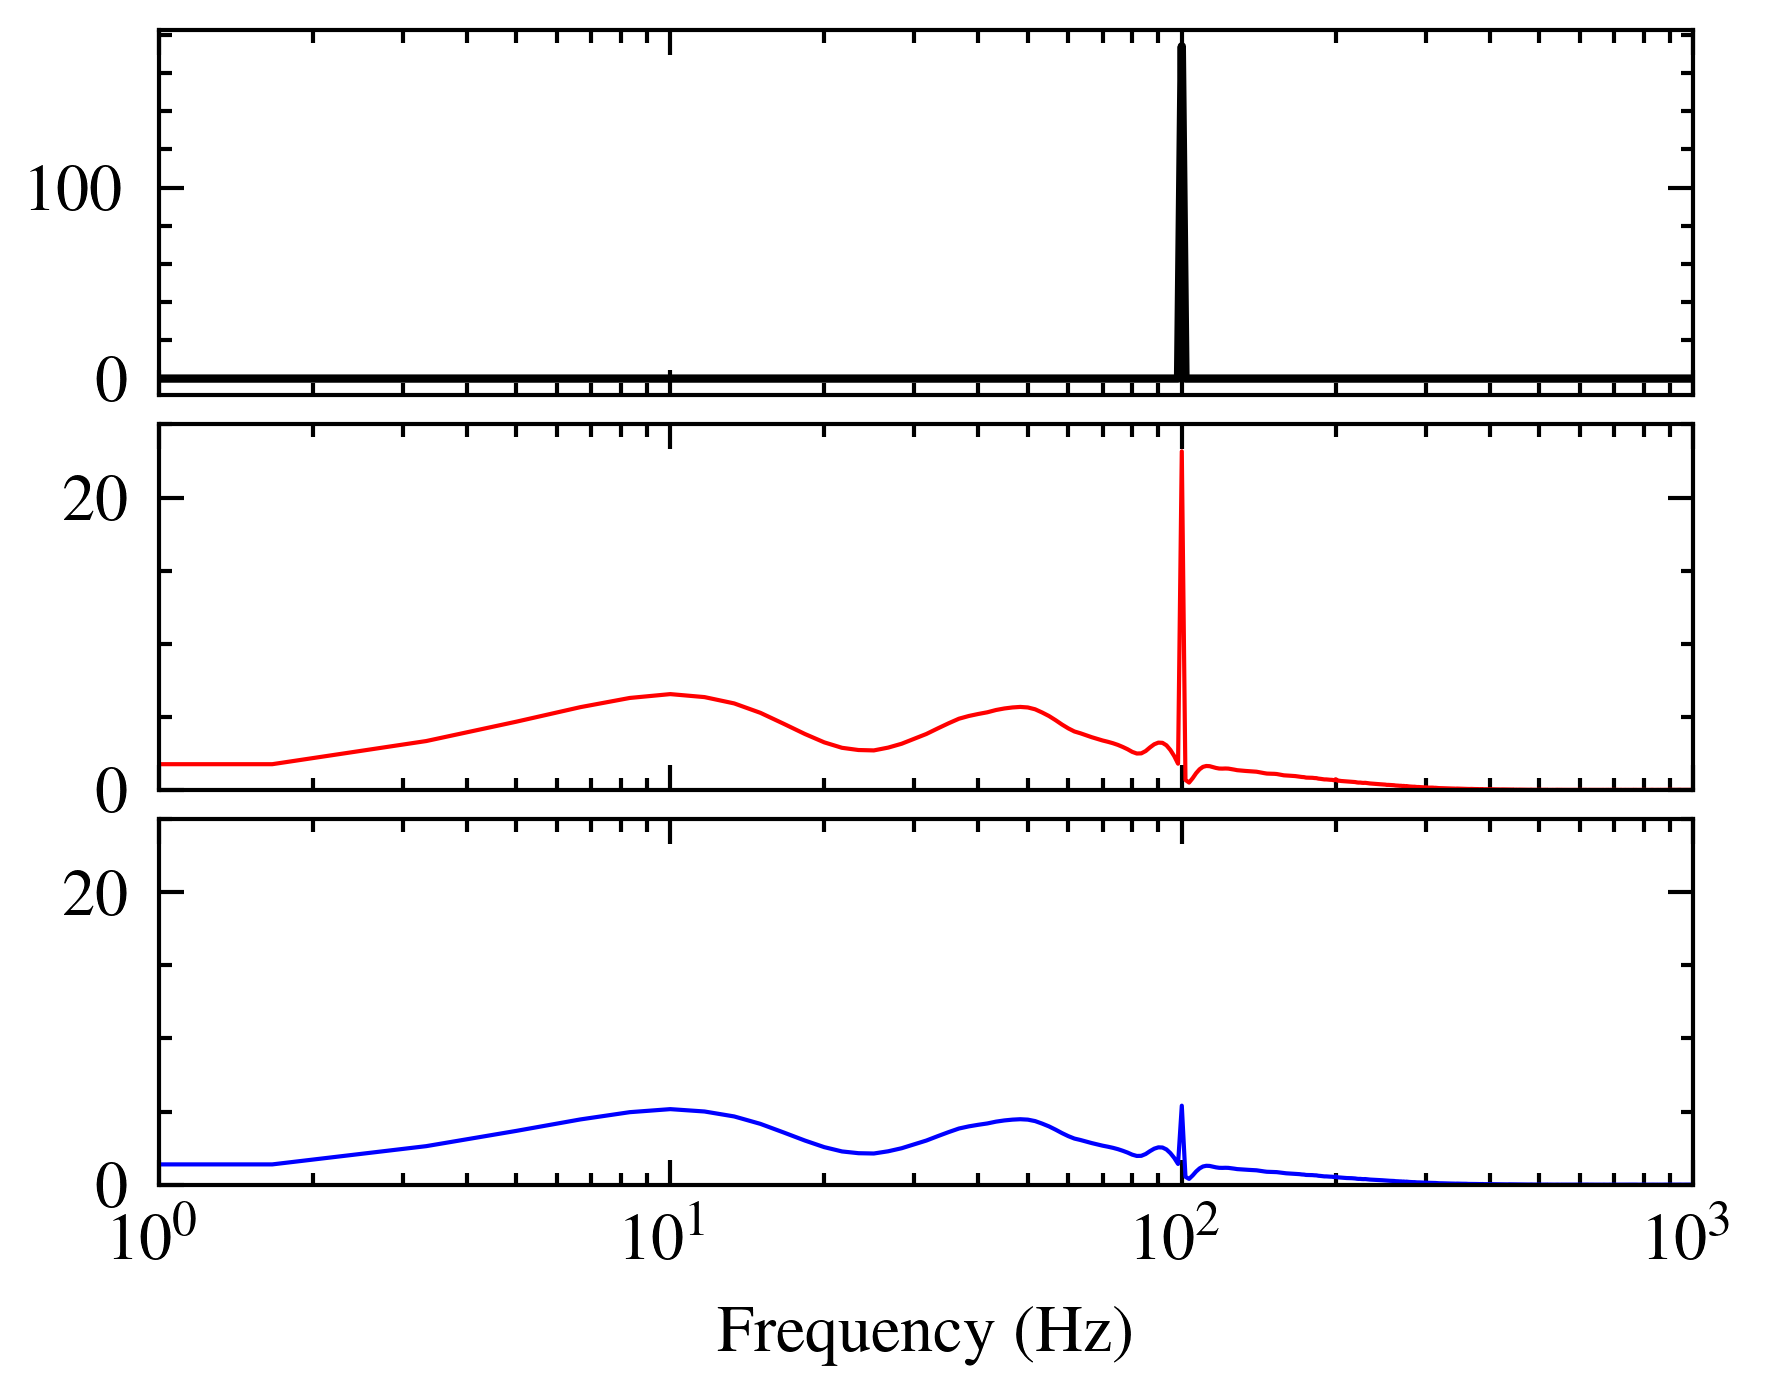

In [36]:
fig = plt.figure()
gs = gridspec.GridSpec(3, 1, height_ratios=[1, 1, 1]) 

ax4 = plt.subplot(gs[0])
X = np.fft.rfft(voltage[0:range_idx])
freq = np.fft.rfftfreq(len(voltage[0:range_idx]), 1/sample_rate)
ax4.semilogx(freq, np.abs(X)/len(voltage[0:range_idx]), label="Baseline Current")

ax5 = plt.subplot(gs[1])
X = np.fft.rfft(current[start_idx:end_idx])
freq = np.fft.rfftfreq(len(current[start_idx:end_idx]), 1/sample_rate)
ax5.semilogx(freq, np.abs(X)/len(current[start_idx:end_idx]), label="Baseline Current",color='red')

ax6 = plt.subplot(gs[2])
X = np.fft.rfft(cancelled[start_idx:end_idx])
freq = np.fft.rfftfreq(len(cancelled[start_idx:end_idx]), 1/sample_rate)
ax6.semilogx(freq, np.abs(X)/len(cancelled[start_idx:end_idx]), label="Baseline Current",color='blue')


x_lims = [1,1000]
ax4.set_xlim(x_lims)
ax5.set_xlim(x_lims)
ax6.set_xlim(x_lims)

ax4.set_ylim([0,200])
ax5.set_ylim([0,25])
ax6.set_ylim([0,25])


plt.setp(ax4.get_xticklabels(), visible=False)
plt.setp(ax5.get_xticklabels(), visible=False)
plt.subplots_adjust(hspace=.08)

ax6.set_xlabel('Frequency (Hz)')

plt.style.use(['science','ieee'])

fig.align_ylabels()

plt.show